# Лабораторная работа 7. Полносвязные нейронные сети (FCNN). Решение задачи регрессии

## Загрузка данных и понижение размерности

In [1]:


import matplotlib.pyplot as plt
import optuna
from matplotlib.lines import lineStyles
from sklearn.compose import ColumnTransformer

from sklearn.feature_selection import VarianceThreshold

import pandas as pd
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearnex.model_selection import train_test_split


C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data = pd.read_csv("datasets/air.csv", index_col = 0)

X, y = data.drop("CO(GT)", axis=1), data["CO(GT)"]

selector_vt = VarianceThreshold(threshold=0.015)
X_vt = selector_vt.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_vt, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

print(f"Исходные признаки: {X.columns.tolist()}, количество: {len(X.columns.tolist())}")
print(f"Признаки после понижения размерности: {X.columns[selector_vt.get_support()].tolist()},"
      f" количество: {len(X.columns[selector_vt.get_support()].tolist())}")

Исходные признаки: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'day', 'month', 'day_of_week', 'hour', 'year'], количество: 15
Признаки после понижения размерности: ['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH', 'day', 'month', 'day_of_week', 'hour', 'year'], количество: 14


## FCNN (MLP) из библиотеки Scikit-learn

In [3]:
columns = [
    'Regressor', 'Search strategy',
    'Train_R2', 'Train_MSE', 'Train_MAE',
    'Test_R2', 'Test_MSE', 'Test_MAE', 'Epochs', 'Solver'
]
table = pd.DataFrame(columns=columns)
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver


In [4]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


def input_into_table(name, search_name, model, X_train, y_train, X_test, y_test):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Regressor': name,
        'Search strategy': search_name,
        'Train_R2': round(r2_score(y_train, train_pred), 2),
        'Train_MSE': round(mean_squared_error(y_train, train_pred), 4),
        'Train_MAE': round(mean_absolute_error(y_train, train_pred), 4),
        'Test_R2': round(r2_score(y_test, test_pred), 2),
        'Test_MSE': round(mean_squared_error(y_test, test_pred), 4),
        'Test_MAE': round(mean_absolute_error(y_test, test_pred), 4),
        'Epochs': model.n_iter_,
        'Solver': model.solver
    }

    table.loc[len(table)] = new_row

### Optuna

In [12]:
def objective(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical('hidden_layer_sizes', [(100,), (50, 50), (100, 50)]),

        'solver': trial.suggest_categorical('solver', ['adam', 'sgd', 'lbfgs']),

        'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),

        'alpha': trial.suggest_float('alpha', 1e-5, 1e-2, log=True),

        'learning_rate': trial.suggest_categorical('learning_rate', ['constant', 'adaptive']),
        'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True)
    }

    regressor = MLPRegressor(**params, random_state=15, max_iter=1000)

    score = cross_val_score(regressor, X_train, y_train, cv=5, n_jobs=-1, scoring="r2").mean()

    return score

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=100)

print(f"Лучшие параметры: {study.best_params}")

[I 2026-05-06 20:02:29,511] A new study created in memory with name: no-name-6ae14ca7-f3fc-4f06-ad82-45c5a99f4325
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100,) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (50, 50) which is of type tuple.
  optuna_warn(message)
C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (100, 50) which is of type tuple.
  optuna_warn(messa

Лучшие параметры: {'hidden_layer_sizes': (50, 50), 'solver': 'adam', 'activation': 'relu', 'alpha': 0.004919442310438787, 'learning_rate': 'constant', 'learning_rate_init': 0.000565803717412431}


In [13]:
model = MLPRegressor(**study.best_params, random_state=15)
model.fit(X_train, y_train)
input_into_table("MLPRegressor", "Optuna", model, X_train, y_train, X_test, y_test)
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.74,0.0028,0.0356,0.74,0.0027,0.0346,35,adam


In [61]:
import seaborn as sns
def make_graphic(model, name):
    fig, axes = plt.subplots(1, 2)

    sns.kdeplot(y_train, ax=axes[0], label="Истинные значения")
    sns.kdeplot(model.predict(X_train), ax=axes[0], label="Предсказанные значения", linestyle="--", color="red")
    axes[0].set_title("Train")

    sns.kdeplot(y_test, ax=axes[1], label="Истинные значения")
    sns.kdeplot(model.predict(X_test), ax=axes[1], label="Предсказанные значения", linestyle="--", color="red")
    axes[1].set_title("Test")

    axes[0].grid(True, alpha=0.3)
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(name)

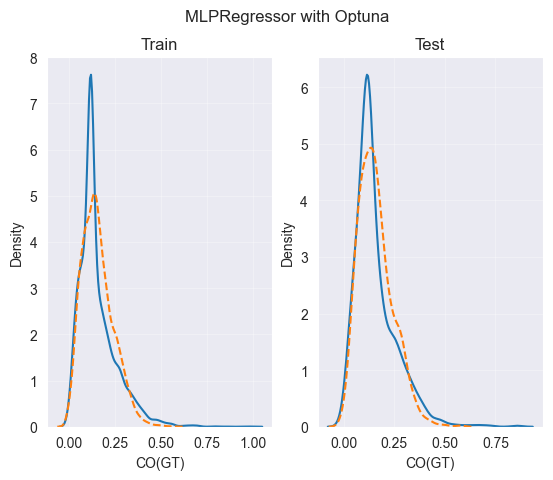

In [14]:


make_graphic(model, "MLPRegressor with Optuna")

In [15]:
print(f"Архитектура сети: {model.hidden_layer_sizes}")

print(f"Количество слоев: {model.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in model.coefs_]}")

Архитектура сети: (50, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(14, 50), (50, 50), (50, 1)]


Text(0, 0.5, 'Loss (MSE)')

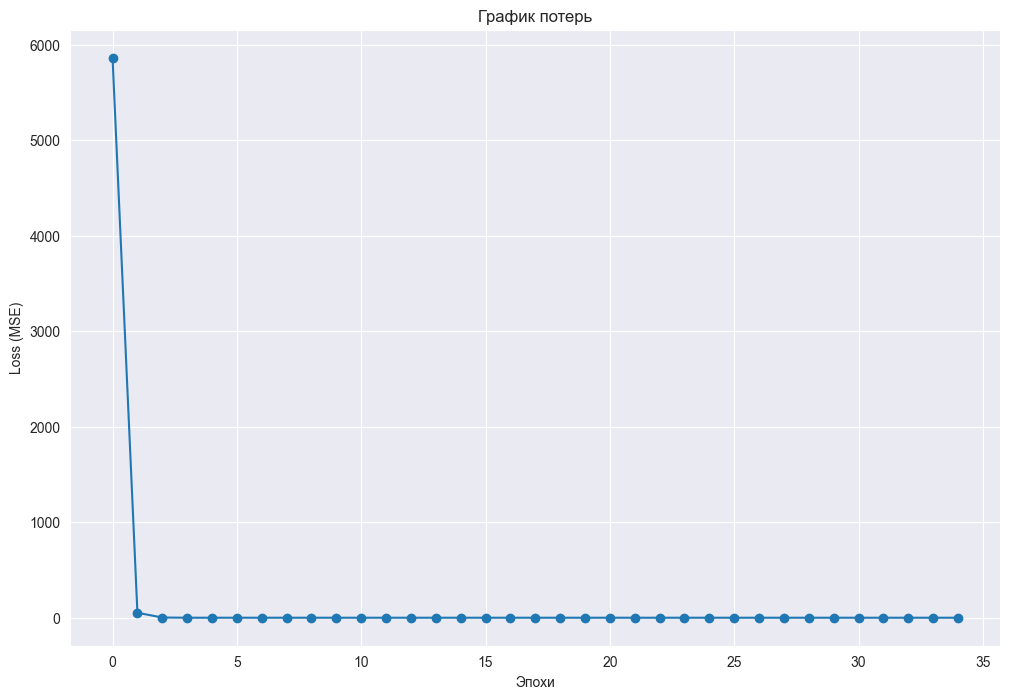

In [16]:
plt.figure(figsize=(12, 8))
plt.plot(model.loss_curve_, marker='o')
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

### RandomizeSearchCV

In [17]:
param_dist = {
    'hidden_layer_sizes': [(100,), (50, 50), (100, 50)],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2],
    'learning_rate': ['constant', 'adaptive'],
    'learning_rate_init': [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
}

mlp = MLPRegressor(max_iter=1000)

rs = RandomizedSearchCV(estimator=mlp,
                        param_distributions=param_dist,
                        n_jobs=-1,
                        cv=5,
                        scoring="r2",
                        verbose=3)

rs.fit(X_train, y_train)
input_into_table("MLPRegressor", "RandomizedSearch", rs.best_estimator_, X_train, y_train, X_test, y_test)
table

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.74,0.0028,0.0356,0.74,0.0027,0.0346,35,adam
1,MLPRegressor,RandomizedSearch,0.64,0.0038,0.0439,0.65,0.0036,0.0424,77,lbfgs


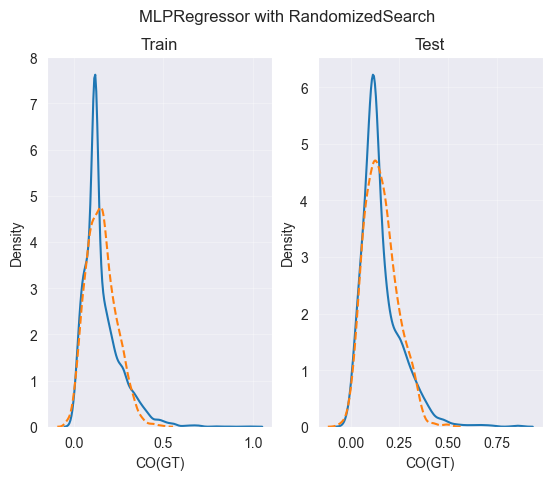

In [18]:
make_graphic(rs.best_estimator_, "MLPRegressor with RandomizedSearch")

In [19]:
print(f"Архитектура сети: {rs.best_estimator_.hidden_layer_sizes}")

print(f"Количество слоев: {rs.best_estimator_.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in rs.best_estimator_.coefs_]}")

Архитектура сети: (100, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(14, 100), (100, 50), (50, 1)]


### Hyperport

In [20]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import numpy as np

layers = [(100,), (50, 50), (100, 50)]
solvers = ['adam', 'sgd', 'lbfgs']
activations = ['relu', 'tanh']
learning_rates = ['constant', 'adaptive']

space = {
    'hidden_layer_sizes': hp.choice('hidden_layer_sizes', layers),
    'solver': hp.choice('solver', solvers),
    'activation': hp.choice('activation', activations),
    'alpha': hp.loguniform('alpha', np.log(1e-5), np.log(1e-2)),
    'learning_rate': hp.choice('learning_rate', learning_rates),
    'learning_rate_init': hp.loguniform('learning_rate_init', np.log(1e-4), np.log(1e-2))
}


def objective(params):
    model = MLPRegressor(**params, max_iter=2000, random_state=42)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    return {'loss': -score, 'status': STATUS_OK}

trials = Trials()
best_indices = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=100, trials=trials)

best_params = {
    'hidden_layer_sizes': layers[best_indices['hidden_layer_sizes']],
    'solver': solvers[best_indices['solver']],
    'activation': activations[best_indices['activation']],
    'alpha': best_indices['alpha'],
    'learning_rate': learning_rates[best_indices['learning_rate']],
    'learning_rate_init': best_indices['learning_rate_init']
}


best_model_hyperopt = MLPRegressor(**best_params, max_iter=2000, random_state=42).fit(X_train, y_train)
input_into_table("MLPRegressor", "Hyperopt", best_model_hyperopt, X_train, y_train, X_test, y_test)

print("Лучшие параметры Hyperopt:", best_params)

 29%|██▉       | 29/100 [01:50<08:34,  7.24s/trial, best loss: -0.510728108025941] 

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the o

 30%|███       | 30/100 [03:56<50:02, 42.89s/trial, best loss: -0.510728108025941]

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(



 74%|███████▍  | 74/100 [08:48<04:30, 10.41s/trial, best loss: -0.7264018244360387]

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the o

 75%|███████▌  | 75/100 [10:51<18:18, 43.95s/trial, best loss: -0.7264018244360387]

C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(



100%|██████████| 100/100 [13:00<00:00,  7.80s/trial, best loss: -0.7264018244360387]
Лучшие параметры Hyperopt: {'hidden_layer_sizes': (50, 50), 'solver': 'lbfgs', 'activation': 'relu', 'alpha': 2.2834735009151933e-05, 'learning_rate': 'adaptive', 'learning_rate_init': 0.00010787935512508819}


In [21]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.74,0.0028,0.0356,0.74,0.0027,0.0346,35,adam
1,MLPRegressor,RandomizedSearch,0.64,0.0038,0.0439,0.65,0.0036,0.0424,77,lbfgs
2,MLPRegressor,Hyperopt,0.75,0.0027,0.0353,0.75,0.0026,0.0339,196,lbfgs


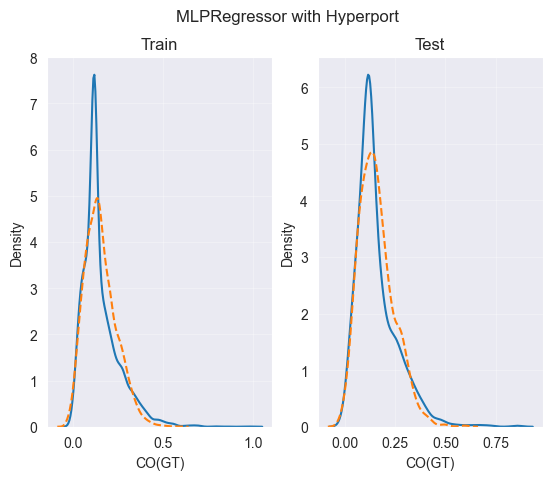

In [22]:
make_graphic(best_model_hyperopt, "MLPRegressor with Hyperport")

In [23]:
print(f"Архитектура сети: {best_model_hyperopt.hidden_layer_sizes}")

print(f"Количество слоев: {best_model_hyperopt.n_layers_}")

print(f"Количество весов (коэффициентов): {[coef.shape for coef in best_model_hyperopt.coefs_]}")

Архитектура сети: (50, 50)
Количество слоев: 4
Количество весов (коэффициентов): [(14, 50), (50, 50), (50, 1)]


## Keras

In [5]:
import keras
def input_into_table_keras(name, search_name, model, X_train, y_train, X_test, y_test, history):

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    new_row = {
        'Regressor': name,
        'Search strategy': search_name,
        'Train_R2': round(r2_score(y_train, train_pred), 2),
        'Train_MSE': round(mean_squared_error(y_train, train_pred), 4),
        'Train_MAE': round(mean_absolute_error(y_train, train_pred), 4),
        'Test_R2': round(r2_score(y_test, test_pred), 2),
        'Test_MSE': round(mean_squared_error(y_test, test_pred), 4),
        'Test_MAE': round(mean_absolute_error(y_test, test_pred), 4),
        'Epochs': len(history.history['loss']),
        'Solver': model.optimizer.__class__.__name__
    }

    table.loc[len(table)] = new_row

optimizers_dict = {
    "adam": keras.optimizers.Adam,
    "sgd": keras.optimizers.SGD,
    "rmsprop": keras.optimizers.RMSprop,
}

### Optuna

In [55]:
import numpy as np
import pandas as pd
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold

def objective(trial):
    n_layers = trial.suggest_int("n_layers", 1, 5)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "tanh", "elu"])
    opt_name = trial.suggest_categorical("optimizer", list(optimizers_dict.keys()))
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = keras.Sequential()
        model.add(layers.Input(shape=(X_t.shape[1],)))

        for i in range(n_layers):
            num_hidden = trial.suggest_int(f"n_units_l{i}", 16, 512, log=True)
            model.add(layers.Dense(num_hidden, activation=activation))
            dropout_rate = trial.suggest_float(f"dropout_l{i}", 0.0, 0.3)
            model.add(layers.Dropout(dropout_rate))

        model.add(layers.Dense(1, activation="linear"))

        optimizer = optimizers_dict[opt_name](learning_rate=learning_rate)
        model.compile(
            optimizer=optimizer,
            loss="mean_squared_error",
            metrics=["mean_absolute_error"]
        )

        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )

        model.fit(
            X_t, y_t,
            validation_data=(X_v, y_v),
            epochs=100,
            batch_size=batch_size,
            callbacks=[early_stop],
            verbose=0
        )

        y_pred = model.predict(X_v, verbose=0)
        score = r2_score(y_v, y_pred)
        scores.append(score)

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(f"Лучшая ошибка (MAE): {study.best_value}")
print(f"Параметры: {study.best_params}")



[I 2026-05-06 20:59:28,187] A new study created in memory with name: no-name-5e543983-4539-488b-8285-4429b8ccf2fb
[I 2026-05-06 20:59:42,616] Trial 0 finished with value: -7.606270020003396e-05 and parameters: {'n_layers': 4, 'learning_rate': 0.000826313316242756, 'activation': 'tanh', 'optimizer': 'adam', 'batch_size': 64, 'n_units_l0': 118, 'dropout_l0': 0.014434018545902082, 'n_units_l1': 58, 'dropout_l1': 0.13506280855195116, 'n_units_l2': 182, 'dropout_l2': 0.2811561659982015, 'n_units_l3': 512, 'dropout_l3': 0.24865754496490028}. Best is trial 0 with value: -7.606270020003396e-05.
[I 2026-05-06 21:00:16,134] Trial 1 finished with value: -12567844473343.74 and parameters: {'n_layers': 2, 'learning_rate': 0.00018781249734059068, 'activation': 'relu', 'optimizer': 'sgd', 'batch_size': 128, 'n_units_l0': 60, 'dropout_l0': 0.12391908961018933, 'n_units_l1': 16, 'dropout_l1': 0.0674427026841334}. Best is trial 0 with value: -7.606270020003396e-05.
[I 2026-05-06 21:00:52,635] Trial 2 fi

Лучшая ошибка (MAE): 0.169847901146272
Параметры: {'n_layers': 2, 'learning_rate': 0.0015182482356791167, 'activation': 'elu', 'optimizer': 'rmsprop', 'batch_size': 64, 'n_units_l0': 43, 'dropout_l0': 0.22976275755935585, 'n_units_l1': 100, 'dropout_l1': 0.10788277654262489}


In [56]:
import keras
params = study.best_params
model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))


for i in range(params["n_layers"]):
    model.add(layers.Dense(
        params[f"n_units_l{i}"],
        activation=params["activation"]
    ))
    if f"dropout_l{i}" in params:
        model.add(layers.Dropout(params[f"dropout_l{i}"]))

model.add(layers.Dense(1, activation="linear"))

model.compile(
    optimizer=optimizers_dict[params["optimizer"]](learning_rate=params["learning_rate"]),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=study.best_params["batch_size"],
    verbose=2
)

Epoch 1/100
111/111 - 1s - 6ms/step - loss: 6022.5132 - mae: 54.1578 - val_loss: 667.8231 - val_mae: 25.8368
Epoch 2/100
111/111 - 0s - 2ms/step - loss: 363.2342 - mae: 13.9788 - val_loss: 24.0122 - val_mae: 4.8983
Epoch 3/100
111/111 - 0s - 2ms/step - loss: 18.8227 - mae: 2.9243 - val_loss: 0.0537 - val_mae: 0.2095
Epoch 4/100
111/111 - 0s - 2ms/step - loss: 0.4990 - mae: 0.4564 - val_loss: 0.0219 - val_mae: 0.1102
Epoch 5/100
111/111 - 0s - 2ms/step - loss: 0.0709 - mae: 0.2085 - val_loss: 0.0113 - val_mae: 0.0864
Epoch 6/100
111/111 - 0s - 2ms/step - loss: 0.0425 - mae: 0.1624 - val_loss: 0.0156 - val_mae: 0.1093
Epoch 7/100
111/111 - 0s - 2ms/step - loss: 0.0312 - mae: 0.1375 - val_loss: 0.0110 - val_mae: 0.0844
Epoch 8/100
111/111 - 0s - 2ms/step - loss: 0.0246 - mae: 0.1224 - val_loss: 0.0274 - val_mae: 0.1502
Epoch 9/100
111/111 - 0s - 2ms/step - loss: 0.0200 - mae: 0.1099 - val_loss: 0.0175 - val_mae: 0.0932
Epoch 10/100
111/111 - 0s - 2ms/step - loss: 0.0180 - mae: 0.1042 - va

In [57]:
input_into_table_keras("FCNN (Keras)", "Optuna", model, X_train, y_train, X_test, y_test, history)

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 547us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


In [72]:
table.iloc[5]

Regressor          FCNN (Keras)
Search strategy          Optuna
Train_R2                   0.42
Train_MSE                 0.006
Train_MAE                0.0608
Test_R2                    0.43
Test_MSE                 0.0059
Test_MAE                 0.0588
Epochs                      100
Solver                  RMSprop
Name: 7, dtype: object

Text(0, 0.5, 'Loss (MSE)')

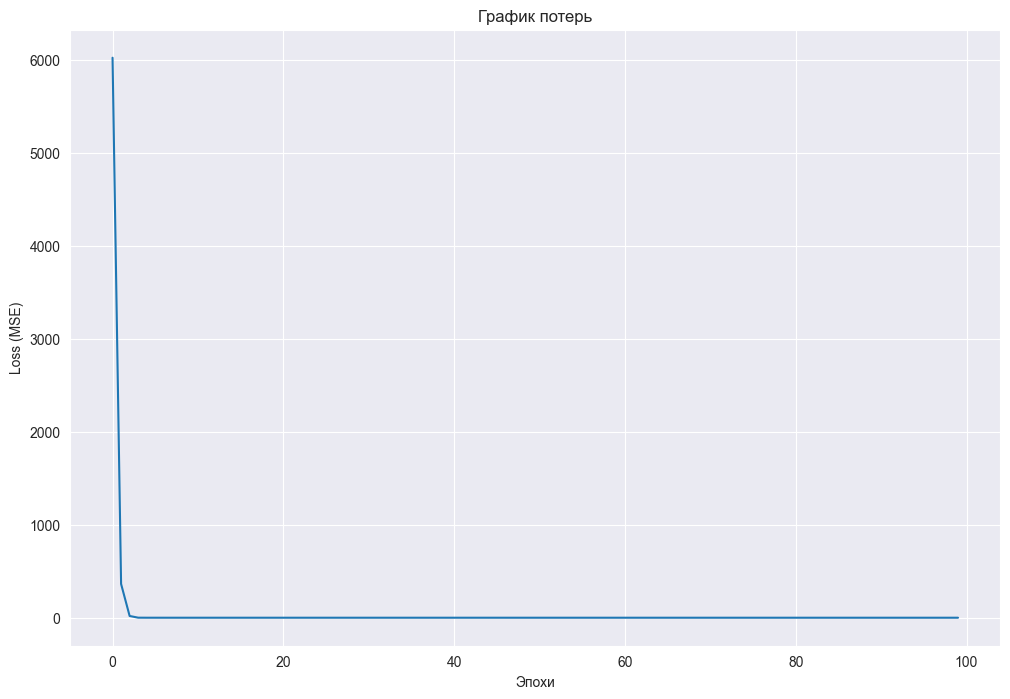

In [59]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


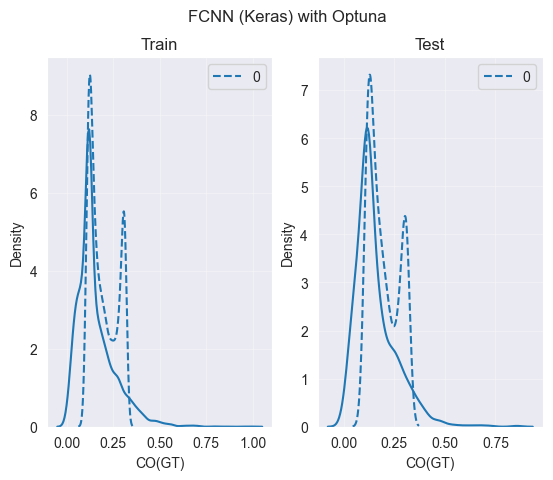

In [62]:
make_graphic(model, "FCNN (Keras) with Optuna")

### KerasTuner

In [32]:
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    for i in range(hp.Int("n_layers", 1, 5)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=512, step=32),
            activation=hp.Choice("activation", ["relu", "tanh", "elu"])
        ))
        if hp.Boolean("dropout"):
            model.add(layers.Dropout(0.2))

    model.add(layers.Dense(1, activation="linear"))

    lr = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")


    optimizer_name = hp.Choice("optimizer", list(optimizers_dict.keys()))

    optimizer = optimizers_dict[optimizer_name](learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=["mae"]
    )
    return model


In [33]:
import keras_tuner as kt
import keras
from keras import layers
tuner = kt.BayesianOptimization(
    build_model,
    objective="val_mae",
    max_trials=20
)


tuner.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), verbose=2)

best_model = tuner.get_best_models(num_models=1)[0]
best_params = tuner.get_best_hyperparameters(num_trials=1)[0]


Reloading Tuner from .\untitled_project\tuner0.json



C:\Users\79585\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\saving\saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [36]:
history = best_model.fit(
    X_train, y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    verbose=2
)

input_into_table_keras(
    name="FCNN (Keras)",
    search_name="KerasTuner (Bayesian)",
    model=best_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    history=history
)


Epoch 1/50
222/222 - 3s - 14ms/step - loss: 0.0037 - mae: 0.0448 - val_loss: 0.0035 - val_mae: 0.0439
Epoch 2/50
222/222 - 1s - 5ms/step - loss: 0.0029 - mae: 0.0390 - val_loss: 0.0029 - val_mae: 0.0410
Epoch 3/50
222/222 - 1s - 5ms/step - loss: 0.0028 - mae: 0.0380 - val_loss: 0.0026 - val_mae: 0.0374
Epoch 4/50
222/222 - 1s - 5ms/step - loss: 0.0031 - mae: 0.0400 - val_loss: 0.0030 - val_mae: 0.0424
Epoch 5/50
222/222 - 1s - 5ms/step - loss: 0.0029 - mae: 0.0386 - val_loss: 0.0022 - val_mae: 0.0327
Epoch 6/50
222/222 - 1s - 5ms/step - loss: 0.0029 - mae: 0.0394 - val_loss: 0.0025 - val_mae: 0.0337
Epoch 7/50
222/222 - 1s - 5ms/step - loss: 0.0028 - mae: 0.0381 - val_loss: 0.0021 - val_mae: 0.0320
Epoch 8/50
222/222 - 1s - 5ms/step - loss: 0.0029 - mae: 0.0380 - val_loss: 0.0021 - val_mae: 0.0326
Epoch 9/50
222/222 - 1s - 5ms/step - loss: 0.0028 - mae: 0.0380 - val_loss: 0.0035 - val_mae: 0.0458
Epoch 10/50
222/222 - 1s - 5ms/step - loss: 0.0027 - mae: 0.0370 - val_loss: 0.0024 - val_

Text(0, 0.5, 'Loss (MSE)')

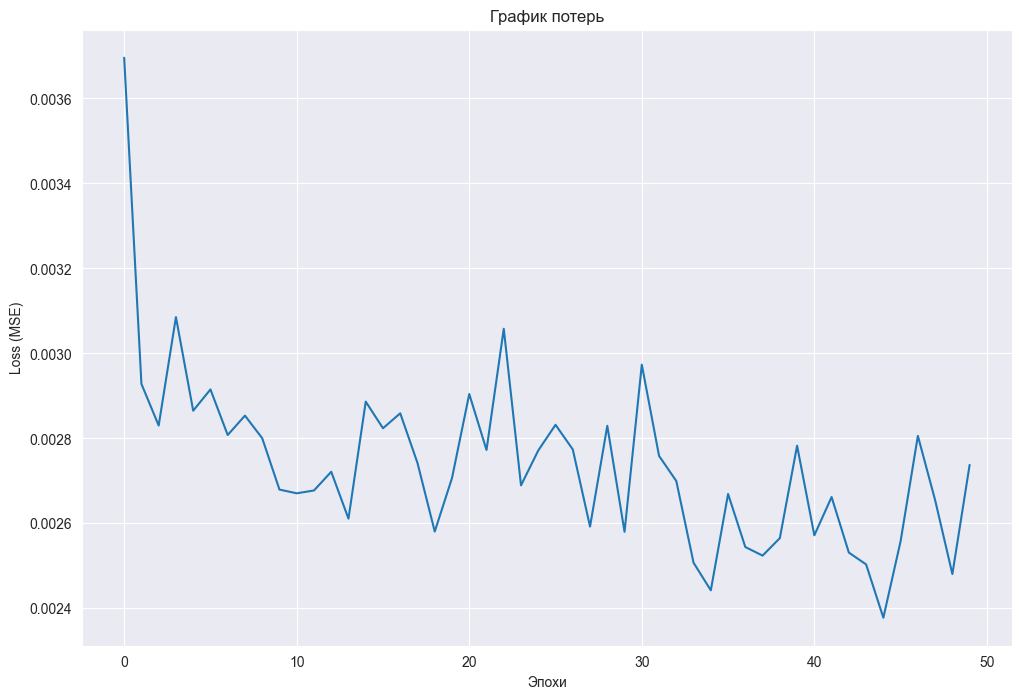

In [38]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


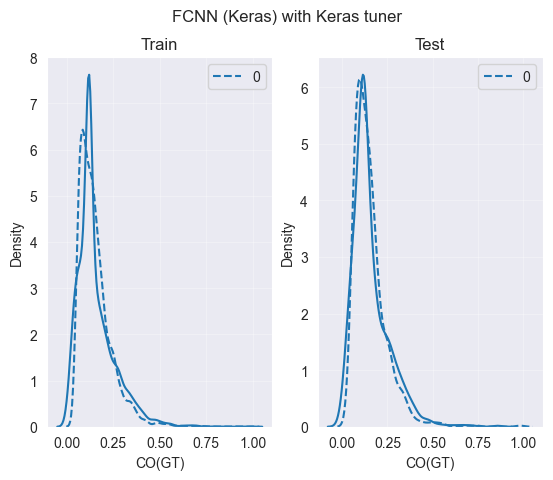

In [63]:
make_graphic(best_model, "FCNN (Keras) with Keras tuner")

In [70]:
table[table["Search strategy"] == "KerasTuner (Bayesian)"]

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
4,FCNN (Keras),KerasTuner (Bayesian),0.8,0.0021,0.0324,0.79,0.0022,0.032,50,Adam


### RayTune

In [9]:
from ray import tune
from sklearn.model_selection import KFold
from ray.train import RunConfig, ScalingConfig
from ray.train.tensorflow import TensorflowTrainer, TensorflowCheckpoint
from ray.tune.integration.keras import TuneReportCheckpointCallback
import tensorflow as tf
from tensorflow.keras import layers, Sequential
import numpy as np
from ray import train
def train_model_ray(config):


    # Кросс-валидация
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    fold_results = []

    opt_map = {
        "adam": tf.keras.optimizers.Adam,
        "sgd": tf.keras.optimizers.SGD,
        "rmsprop": tf.keras.optimizers.RMSprop
    }

    for train_idx, val_idx in kf.split(X_train):
        X_t, X_v = X_train[train_idx], X_train[val_idx]
        y_t, y_v = y_train[train_idx], y_train[val_idx]

        model = Sequential()
        model.add(layers.Input(shape=(X_t.shape[1],)))

        for i in range(config["n_layers"]):
            model.add(layers.Dense(
                units=config[f"units_{i}"],
                activation=config["activation"]
            ))
            if config["dropout"]:
                model.add(layers.Dropout(0.2))

        model.add(layers.Dense(1, activation="linear"))

        optimizer = opt_map[config["optimizer"]](learning_rate=config["lr"])
        model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])

        history = model.fit(
            X_t, y_t,
            epochs=30,
            batch_size=32,
            validation_data=(X_v, y_v),
            verbose=0
        )

        fold_results.append(min(history.history["val_mae"]))

    # Отчет в Ray Tune (обязательно словарем)
    mean_mae = float(np.mean(fold_results))
    tune.report({"val_mae": mean_mae})


search_space = {
    "n_layers": tune.randint(1, 6),
    "activation": tune.choice(["relu", "tanh", "elu"]),
    "dropout": tune.choice([True, False]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "optimizer": tune.choice(list(optimizers_dict.keys())),
}


for i in range(5):
    search_space[f"units_{i}"] = tune.qrandint(32, 512, 32)


tuner = tune.Tuner(
    train_model_ray,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="val_mae",
        mode="min",
        num_samples=20
    )
)

results = tuner.fit()
print("Лучшие параметры:", results.get_best_result().config)


2026-05-07 08:10:31,062	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-07_08-07-56_821718_18784\artifacts\2026-05-07_08-10-30\train_model_ray_2026-05-07_08-10-30\driver_artifacts\train_model_ray_ec684_00000_0_activation=relu,dropout=True,lr=0.0058,n_layers=1,optimizer=rmsprop,units_0=352,units_1=160,units_2=_2026-05-07_08-10-31
2026-05-07 08:10:31,215	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-07_08-07-56_821718_18784\artifacts\2026-05-07_08-10-30\train_model_ray_2026-05-07_08-10-30\driver_artifacts\train_model_ray_ec684_00000_0_activation=relu,dropout=True,lr=0.0058,n_layers=1,optimizer=rmsprop,units_0=352,units_1=160,units_2=_2026-05-07_08-10-31
2026-05-07 08:

2026-05-07 08:10:47,583	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-07_08-07-56_821718_18784\artifacts\2026-05-07_08-10-30\train_model_ray_2026-05-07_08-10-30\driver_artifacts\train_model_ray_ec684_00002_2_activation=relu,dropout=False,lr=0.0005,n_layers=1,optimizer=sgd,units_0=288,units_1=384,units_2=96,_2026-05-07_08-10-31
2026-05-07 08:10:47,735	WARNING trial.py:647 -- The path to the trial log directory is too long (max length: 260. Consider using `trial_dirname_creator` to shorten the path. Path: C:\Users\79585\AppData\Local\Temp\ray\session_2026-05-07_08-07-56_821718_18784\artifacts\2026-05-07_08-10-30\train_model_ray_2026-05-07_08-10-30\driver_artifacts\train_model_ray_ec684_00003_3_activation=elu,dropout=False,lr=0.0039,n_layers=2,optimizer=sgd,units_0=64,units_1=256,units_2=128,u_2026-05-07_08-10-31
2026-05-07 08:

Лучшие параметры: {'n_layers': 4, 'activation': 'elu', 'dropout': False, 'lr': 0.001320912137708591, 'optimizer': 'adam', 'units_0': 480, 'units_1': 288, 'units_2': 64, 'units_3': 256, 'units_4': 192}


In [10]:
config = results.get_best_result().config
model = keras.Sequential()
model.add(layers.Input(shape=(X_train.shape[1],)))

for i in range(config["n_layers"]):
    model.add(layers.Dense(
        units=config[f"units_{i}"],
        activation=config["activation"]
    ))
    if config["dropout"]:
        model.add(layers.Dropout(0.2))

model.add(layers.Dense(1, activation="linear"))


optimizer = optimizers_dict[config["optimizer"]](learning_rate=config["lr"])
model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])


history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    verbose=1
)

input_into_table_keras(
    name="FCNN (Keras)",
    search_name="Ray Tune",
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    history=history
)


Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 733.7026 - mae: 10.4214 - val_loss: 0.0095 - val_mae: 0.0732
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0118 - mae: 0.0816 - val_loss: 0.0098 - val_mae: 0.0786
Epoch 3/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0131 - mae: 0.0855 - val_loss: 0.0134 - val_mae: 0.0789
Epoch 4/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0150 - mae: 0.0959 - val_loss: 0.0169 - val_mae: 0.0933
Epoch 5/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0241 - mae: 0.1227 - val_loss: 0.0317 - val_mae: 0.1514
Epoch 6/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0264 - mae: 0.1294 - val_loss: 0.0422 - val_mae: 0.1832
Epoch 7/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0583 - mae: 0.1926 - val_loss: 0.2066 - val_mae: 0.4452
Epoch 8/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2469 - mae: 0.4076 - val_loss: 0.0867 - val_mae: 0.2802
Epoch 9/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

In [68]:
table[table["Search strategy"] == "Ray Tune"]

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
5,FCNN (Keras),Ray Tune,0.73,0.0029,0.0358,0.72,0.0029,0.035,50,Adam


Text(0, 0.5, 'Loss (MSE)')

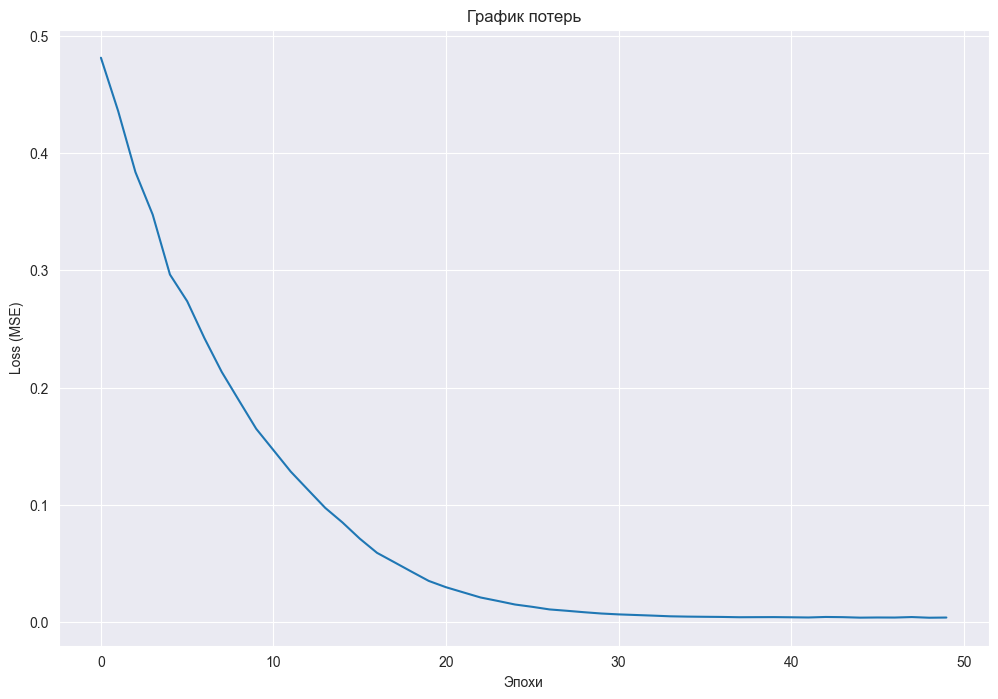

In [47]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['loss'])
plt.title("График потерь")
plt.xlabel("Эпохи")
plt.ylabel("Loss (MSE)")

222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 489us/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


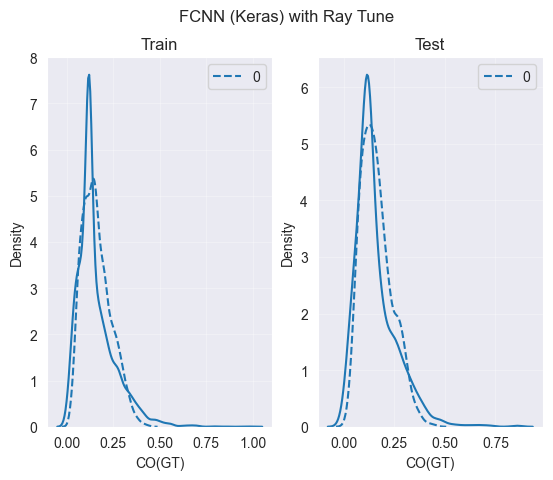

In [48]:
make_graphic(model, "FCNN (Keras) with Ray Tune")

In [67]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.74,0.0028,0.0356,0.74,0.0027,0.0346,35,adam
1,MLPRegressor,RandomizedSearch,0.64,0.0038,0.0439,0.65,0.0036,0.0424,77,lbfgs
2,MLPRegressor,Hyperopt,0.75,0.0027,0.0353,0.75,0.0026,0.0339,196,lbfgs
4,FCNN (Keras),KerasTuner (Bayesian),0.80,0.0021,0.0324,0.79,0.0022,0.0320,50,Adam
5,FCNN (Keras),Ray Tune,0.73,0.0029,0.0358,0.72,0.0029,0.0350,50,Adam
7,FCNN (Keras),Optuna,0.42,0.0060,0.0608,0.43,0.0059,0.0588,100,RMSprop


## Вывод

In [73]:
table

,Regressor,Search strategy,Train_R2,Train_MSE,Train_MAE,Test_R2,Test_MSE,Test_MAE,Epochs,Solver
0,MLPRegressor,Optuna,0.74,0.0028,0.0356,0.74,0.0027,0.0346,35,adam
1,MLPRegressor,RandomizedSearch,0.64,0.0038,0.0439,0.65,0.0036,0.0424,77,lbfgs
2,MLPRegressor,Hyperopt,0.75,0.0027,0.0353,0.75,0.0026,0.0339,196,lbfgs
4,FCNN (Keras),KerasTuner (Bayesian),0.80,0.0021,0.0324,0.79,0.0022,0.0320,50,Adam
5,FCNN (Keras),Ray Tune,0.73,0.0029,0.0358,0.72,0.0029,0.0350,50,Adam
7,FCNN (Keras),Optuna,0.42,0.0060,0.0608,0.43,0.0059,0.0588,100,RMSprop


In [ ]:
best_model

In [77]:
sample_data = np.array([[
    0.5, 
    0.2,
    0.4,
    0.4,
    0.6,
    0.5,
    0.7,
    0.5,
    0.3,
    15,
    3,
    1,
    12,
    2004
]], dtype='float32')

prediction = best_model.predict(sample_data)
print(f"Результат предсказания: {prediction[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Результат предсказания: [0.1952681]
